# CCP-estimator med EM-algoritme og to latente forbrugertyper

Implementerer **Arcidiacono & Miller (2011)** EM-CCP estimatoren som et hurtigere alternativ til EM-NFXP.

## CCP vs. NFXP
| | NFXP | CCP (dette notebook) |
|---|---|---|
| M-trinets indre løser | VFI ved *hvert* optimeringstrin | Hotz-Miller inversion én gang pr. M-trin |
| Beregningsomkostning | Høj | Lav |
| Kræver start-CCPs | Nej | Ja |
| Konsistent | Ja (fuld MLE) | Ja (med tilstrækkelig iteration) |

## Hotz-Miller inversionen
Givet nuværende CCPs $\hat{P}_k$ beregnes value-funktionen via den **lineære** identitet (EV1-modellen):
$$\hat{V}_k(\ell,d,e) = u_0(\ell,d,e;\theta_k) + \delta\sum_{e'}\Pi(e'|e)\,\hat{V}_k(\ell, d_{\text{next}}, e') + \gamma_E - \log \hat{P}_{k0}(\ell,d,e)$$

Dette er en kontraktionsafbildning med rate $\delta = 0.95$ — løses ved simple iterationer.

## EM-CCP løkke
**E-trin:** $w_{i1}^{(m)} = \dfrac{\pi^{(m)} L_i(\hat{P}_1^{(m)})}{\pi^{(m)} L_i(\hat{P}_1^{(m)}) + (1-\pi^{(m)}) L_i(\hat{P}_2^{(m)})}$

**M-trin:** for $k=1,2$:
1. Beregn $\hat{V}_k$ fra $\hat{P}_k$ (Hotz-Miller, ét løkke-gennemløb)
2. Pre-beregn fortsættelsesværdier $EV_k$ — fastholdes under optimering
3. Optimér $\theta_k = \arg\max \sum_i w_{ik} \log \tilde{P}_{y_{it}}(\theta_k, EV_k)$ — **ingen VFI** per funktionsevaluering!
4. Opdater $\hat{P}_k$ fra ny $\theta_k$ og $EV_k$

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from nfxp_agu2022 import (
    J, T, N, D_MAX, DELTA, MU,
    PARAM_NAMES, THETA_TRUE,
    flow_util, unpack, solve_vfi, compute_ccps,
    simulate_panel, _sample_rows,
    PROMO_TRANS, N_PROMO,
    MC_SEED,
)

EULER = 0.5772156649  # Euler-Mascheroni konstant (fra EV1-fordelingen)

print(f'Base-model: J={J}, T={T}, N={N}, D_MAX={D_MAX}, delta={DELTA}')

Base-model: J=2, T=52, N=2000, D_MAX=2, delta=0.95


## 1. Sande DGP-parametre (samme som EM-NFXP)

In [2]:
THETA_1_TRUE = THETA_TRUE.copy()  # type 1: mærkeloyale, lav prisfølsomhed
THETA_2_TRUE = np.array([0.10, 0.80, 0.20, 0.15, 0.40, 0.40])  # type 2: tilbudsjaegere
PI_TRUE      = 0.40

EM_MAXITER = 100
EM_TOL     = 1e-4
EM_MC_REPS = 10
EM_MC_N    = 1_000

PARAM_NAMES_EM = ['pi'] + [f'{n}_k1' for n in PARAM_NAMES] + [f'{n}_k2' for n in PARAM_NAMES]
THETA_EM_TRUE  = np.concatenate([[PI_TRUE], THETA_1_TRUE, THETA_2_TRUE])

print('Type 1:', dict(zip(PARAM_NAMES, THETA_1_TRUE)))
print('Type 2:', dict(zip(PARAM_NAMES, THETA_2_TRUE)))
print(f'pi_true = {PI_TRUE}')

Type 1: {'alpha_2': 0.3, 'gamma': 0.5, 'beta_sc_12': 0.55, 'beta_sc_21': 0.5, 'beta_dep_1': 0.25, 'beta_dep_2': 0.25}
Type 2: {'alpha_2': 0.1, 'gamma': 0.8, 'beta_sc_12': 0.2, 'beta_sc_21': 0.15, 'beta_dep_1': 0.4, 'beta_dep_2': 0.4}
pi_true = 0.4


## 2. Hjælpefunktioner (deles med EM-NFXP)

In [3]:
def log_likelihood_per_consumer(data, P):
    """(N,) array: sum_t log P(y_it | state_it) for each consumer."""
    Y, L, D, E = data['Y'], data['L'], data['D'], data['E_IDX']
    return np.sum(np.log(np.maximum(P[L-1, D, E, Y], 1e-300)), axis=1)


def em_e_step(ll1, ll2, pi):
    """E-trin: posterior P(type=1 | data_i) i log-rum."""
    log_pi1 = np.log(np.clip(pi,       1e-300, 1-1e-300))
    log_pi2 = np.log(np.clip(1.0-pi,   1e-300, 1-1e-300))
    log_num1  = log_pi1 + ll1
    log_num2  = log_pi2 + ll2
    return np.exp(log_num1 - np.logaddexp(log_num1, log_num2))


def canonicalize(pi, theta1, theta2):
    """Type 1 = lavest gamma — forhindrer label-switching i Monte Carlo."""
    if float(theta1[1]) > float(theta2[1]):
        return 1.0 - pi, theta2.copy(), theta1.copy()
    return float(pi), theta1.copy(), theta2.copy()


def simulate_panel_2types(P1_true, P2_true, pi_true=PI_TRUE,
                          n_consumers=N, n_periods=T, seed=None):
    """Simulerer to-type panel — identisk med EM-NFXP versionen."""
    rng = np.random.default_rng(seed)
    type1_mask = rng.random(n_consumers) < pi_true
    types = np.where(type1_mask, 1, 2).astype(int)
    Y = np.zeros((n_consumers, n_periods), dtype=int)
    L = np.zeros((n_consumers, n_periods), dtype=int)
    D = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)
    ell   = rng.integers(1, J+1,    size=n_consumers)
    dur   = rng.integers(0, D_MAX+1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO, size=n_consumers)
    for t in range(n_periods):
        L[:,t] = ell; D[:,t] = dur; E_IDX[:,t] = e_idx
        probs1 = P1_true[ell-1, np.minimum(dur,D_MAX), e_idx, :]
        probs2 = P2_true[ell-1, np.minimum(dur,D_MAX), e_idx, :]
        probs  = np.where(type1_mask[:,None], probs1, probs2)
        y = _sample_rows(rng, probs); Y[:,t] = y
        bought = y > 0
        ell   = np.where(bought, y, ell)
        dur   = np.where(bought, 0, np.minimum(dur+1, D_MAX))
        e_idx = _sample_rows(rng, PROMO_TRANS[e_idx])
    return {'Y': Y, 'L': L, 'D': D, 'E_IDX': E_IDX, 'TYPE': types}

## 3. CCP-kernefunktioner

In [4]:
def empirical_ccps(data, smoothing=0.5):
    """
    Ikke-parametrisk frekvensestimator af CCPs.

    For hvert tilstandspunkt (l, d, e) tælles andelen af hvert valg.
    'smoothing' tilføjer en prior (Laplace-glatning) for at undgå log(0).
    """
    Y = data['Y'].ravel()
    L = data['L'].ravel()
    D = data['D'].ravel()
    E = data['E_IDX'].ravel()
    counts = np.full((J, D_MAX+1, N_PROMO, J+1), smoothing)
    np.add.at(counts, (L-1, D, E, Y), 1.0)
    return counts / counts.sum(axis=3, keepdims=True)


def ccp_value_function(P_hat, alpha, gamma, beta_sc, beta_dep,
                       tol=1e-10, max_iter=2_000):
    """
    Hotz-Miller inversion: beregner value-funktion fra CCPs.

    Løser det lineære system iterativt:
        V(l,d,e) = u_0(l,d,e;theta) + delta*sum_e' Pi(e'|e)*V(l, d_next, e')
                   + euler - log P_hat_0(l,d,e)

    Dette er en kontraktionsafbildning (rate delta) — konvergerer som VFI.
    Returnerer V array (J, D_MAX+1, N_PROMO).
    """
    V = np.zeros((J, D_MAX+1, N_PROMO))
    log_p0 = np.log(np.maximum(P_hat[:, :, :, 0], 1e-300))  # (J, D_MAX+1, N_PROMO)

    for _ in range(max_iter):
        # E[V(l, d_next, e') | e] for the no-purchase continuation
        EV = (V.reshape(J*(D_MAX+1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX+1, N_PROMO)
        V_new = np.empty_like(V)

        for l_idx in range(J):
            ell = l_idx + 1
            for d in range(D_MAX+1):
                d_next = min(d+1, D_MAX)
                for e in range(N_PROMO):
                    u0 = flow_util(0, ell, d, e, alpha, gamma, beta_sc, beta_dep)
                    V_new[l_idx, d, e] = (u0 + DELTA * EV[l_idx, d_next, e]
                                         + EULER - log_p0[l_idx, d, e])

        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V


def precompute_ev(V_hat):
    """
    Pre-beregner delta*E[V_hat(next state, e')] for alle tilstande og valg.

    Returnerer EV array (J, D_MAX+1, N_PROMO) identisk med compute_ccps.
    Denne er FASTHOLDT under M-trinets optimizer — ingen VFI per kald!
    """
    return DELTA * (V_hat.reshape(J*(D_MAX+1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX+1, N_PROMO)


def ccps_from_ev(EV, alpha, gamma, beta_sc, beta_dep):
    """
    Beregner CCPs givet pre-beregnede fortsættelsesværdier EV.

    Hver Q(j) = u_j(theta) + EV(next_j)  — EV er fast, kun u_j varierer med theta.
    Softmax over Q giver CCPs. Ingen VFI nødvendig!
    """
    P = np.empty((J, D_MAX+1, N_PROMO, J+1))
    for l_idx in range(J):
        ell = l_idx + 1
        for d in range(D_MAX+1):
            d_next = min(d+1, D_MAX)
            for e in range(N_PROMO):
                Q = np.empty(J+1)
                Q[0] = (flow_util(0, ell, d, e, alpha, gamma, beta_sc, beta_dep)
                        + EV[l_idx, d_next, e])
                for j_idx in range(J):
                    Q[j_idx+1] = (flow_util(j_idx+1, ell, d, e, alpha, gamma, beta_sc, beta_dep)
                                  + EV[j_idx, 0, e])
                q_s = Q - Q.max()
                w   = np.exp(q_s)
                P[l_idx, d, e, :] = w / w.sum()
    return P

## 4. CCP M-trin: vægtet objektfunktion

In [5]:
def ccp_objective_weighted(theta, data, weights, EV):
    """
    Vægtet negativ pseudo-log-sandsynlighed for CCP M-trin.

    EV er PRE-BEREGNET og fastholdt — objektfunktionen kræver kun
    evaluering af flow_util per kald (ingen VFI!).
    Beregningsbesparelse ift. NFXP: ~100x per funktionsevaluering.
    """
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    P  = ccps_from_ev(EV, alpha, gamma, beta_sc, beta_dep)
    ll = log_likelihood_per_consumer(data, P)  # (N,)
    return -float(np.dot(weights, ll))


def estimate_ccp_weighted(data, weights, EV, theta0=None):
    """CCP M-trin solver: Nelder-Mead over vægtet pseudo-LL med fast EV."""
    if theta0 is None:
        theta0 = np.array([0.1, 0.3, 0.3, 0.3, 0.1, 0.1])
    return minimize(
        fun=ccp_objective_weighted,
        x0=theta0,
        args=(data, weights, EV),
        method='Nelder-Mead',
        options={'maxiter': 10_000, 'xatol': 1e-5, 'fatol': 1e-5, 'adaptive': True},
    )

## 5. EM-CCP algoritmen (Arcidiacono & Miller 2011)

In [6]:
def estimate_em_ccp(data, pi0, theta1_0, theta2_0, P1_init, P2_init,
                    n_iter=EM_MAXITER, tol_em=EM_TOL, verbose=True):
    """
    EM-CCP algoritme for to-type blandingsmodellen.

    E-trin  : beregn posteriors fra nuværende CCPs (log-rum for stabilitet).
    M-trin  : for type k:
              1) Hotz-Miller inversion  -> V_hat_k  (ét iterativt løkke-gennemløb)
              2) Pre-beregn EV_k        -> fastholdes under optimering
              3) Nelder-Mead over CCP pseudo-LL  -> theta_k_new  (ingen VFI!)
              4) Opdater P_k fra ny theta_k og EV_k

    Returnerer dict: pi, theta1, theta2, P1, P2, history, n_iter, converged.
    """
    pi     = float(pi0)
    theta1 = theta1_0.copy(); theta2 = theta2_0.copy()
    P1     = P1_init.copy();  P2     = P2_init.copy()
    history = []

    if verbose:
        n_obs, t_obs = data['Y'].shape
        print(f'EM-CCP  (K=2)  |  N={n_obs}, T={t_obs}')
        print(f'  Start  pi={pi:.3f}')
        print(f'         theta1={np.round(theta1, 3)}')
        print(f'         theta2={np.round(theta2, 3)}')
        print(f"\n  {'Iter':>4}  {'pi':>7}  {'delta':>10}")
        print('  ' + '-' * 26)

    for it in range(1, n_iter + 1):

        # ── E-trin ────────────────────────────────────────────────────────
        ll1 = log_likelihood_per_consumer(data, P1)
        ll2 = log_likelihood_per_consumer(data, P2)
        w1  = em_e_step(ll1, ll2, pi)
        w2  = 1.0 - w1
        pi_new = float(w1.mean())

        # ── M-trin: type 1 ────────────────────────────────────────────────
        a1, g1, sc1, d1 = unpack(theta1)
        V1_hat  = ccp_value_function(P1, a1, g1, sc1, d1)   # Hotz-Miller
        EV1     = precompute_ev(V1_hat)                      # fast under opt.
        if w1.sum() > 1e-6:
            res1       = estimate_ccp_weighted(data, w1, EV1, theta0=theta1)
            theta1_new = res1.x
        else:
            theta1_new = theta1
        P1_new = ccps_from_ev(EV1, *unpack(theta1_new))     # opdater CCPs

        # ── M-trin: type 2 ────────────────────────────────────────────────
        a2, g2, sc2, d2 = unpack(theta2)
        V2_hat  = ccp_value_function(P2, a2, g2, sc2, d2)
        EV2     = precompute_ev(V2_hat)
        if w2.sum() > 1e-6:
            res2       = estimate_ccp_weighted(data, w2, EV2, theta0=theta2)
            theta2_new = res2.x
        else:
            theta2_new = theta2
        P2_new = ccps_from_ev(EV2, *unpack(theta2_new))

        # ── Konvergenstjek ────────────────────────────────────────────────
        delta = max(
            abs(pi_new - pi),
            float(np.max(np.abs(theta1_new - theta1))),
            float(np.max(np.abs(theta2_new - theta2))),
        )

        pi, theta1, theta2, P1, P2 = pi_new, theta1_new, theta2_new, P1_new, P2_new
        history.append({'pi': pi, 'theta1': theta1.copy(), 'theta2': theta2.copy()})

        if verbose:
            print(f'  {it:>4}  {pi:>7.4f}  {delta:>10.6f}')

        if delta < tol_em:
            if verbose:
                print(f'\n  => Konvergerede efter {it} iterationer.')
            return {'pi': pi, 'theta1': theta1, 'theta2': theta2,
                    'P1': P1, 'P2': P2, 'history': history,
                    'n_iter': it, 'converged': True}

    if verbose:
        print(f'\n  => Konvergerede IKKE efter {n_iter} iterationer.')
    return {'pi': pi, 'theta1': theta1, 'theta2': theta2,
            'P1': P1, 'P2': P2, 'history': history,
            'n_iter': n_iter, 'converged': False}

## 6. Pilot-kørsel

In [7]:
# Løs DP ved sande parametre for begge typer (til DGP-simulation)
a1, g1, sc1, d1 = unpack(THETA_1_TRUE)
a2, g2, sc2, d2 = unpack(THETA_2_TRUE)
V1_true = solve_vfi(a1, g1, sc1, d1);  P1_true = compute_ccps(V1_true, a1, g1, sc1, d1)
V2_true = solve_vfi(a2, g2, sc2, d2);  P2_true = compute_ccps(V2_true, a2, g2, sc2, d2)
print('DGP-DP løst for begge typer.')

# Simulér ét to-type panel
pilot_data = simulate_panel_2types(P1_true, P2_true, pi_true=PI_TRUE, seed=42)
print(f"Realiseret andel type 1: {(pilot_data['TYPE']==1).mean():.3f}  (sand={PI_TRUE})")
print(f"Samlet købsrate:         {(pilot_data['Y']>0).mean():.1%}")

DGP-DP løst for begge typer.
Realiseret andel type 1: 0.395  (sand=0.4)
Samlet købsrate:         49.1%


In [8]:
# Startværdier for EM-CCP
# CCPs initialiseres fra perturbererede versioner af de sande parametre
# snarere end empiriske CCPs — giver bedre adskillelse fra start
theta1_0 = THETA_1_TRUE + np.array([ 0.02,  0.05,  0.03,  0.03,  0.02,  0.02])
theta2_0 = THETA_2_TRUE + np.array([-0.02, -0.05, -0.03, -0.03,  0.02,  0.02])
pi0      = 0.50

# Beregn start-CCPs fra startparametre via VFI
V1_0 = solve_vfi(*unpack(theta1_0));  P1_0 = compute_ccps(V1_0, *unpack(theta1_0))
V2_0 = solve_vfi(*unpack(theta2_0));  P2_0 = compute_ccps(V2_0, *unpack(theta2_0))

t0 = time.perf_counter()
pilot_result = estimate_em_ccp(
    pilot_data, pi0=pi0,
    theta1_0=theta1_0, theta2_0=theta2_0,
    P1_init=P1_0, P2_init=P2_0,
    verbose=True,
)
print(f'\nTotal tid: {time.perf_counter()-t0:.1f}s')

EM-CCP  (K=2)  |  N=2000, T=52
  Start  pi=0.500
         theta1=[0.32 0.55 0.58 0.53 0.27 0.27]
         theta2=[0.08 0.75 0.17 0.12 0.42 0.42]

  Iter       pi       delta
  --------------------------
     1   0.4772    0.099063
     2   0.4761    0.801647
     3   0.4753   16.210482
     4   0.4744  301.111916
     5   0.4735   13.103758
     6   0.9611   73.119084
     7   1.0000    1.682455
     8   0.0045   21.608306
     9   0.9955   28.126064
    10   0.0045  112.269846
    11   0.9955   59.094538
    12   0.0045   30.847090
    13   0.9955   25.039513
    14   0.0045    5.108034
    15   0.9955    3.100553
    16   0.0045   70.769508
    17   0.9955    7.864264
    18   0.0045    6.805916
    19   0.9955    4.170206
    20   0.0045   15.812272
    21   0.9955  102.762660
    22   0.0045   27.711108
    23   0.9955   14.544518
    24   0.0045   33.390247
    25   0.9955   10.300736
    26   0.0045  3000.279792
    27   0.9955  844.255618
    28   0.0045  1070.656804
    29   0.

In [9]:
pi_c, t1_c, t2_c = canonicalize(pilot_result['pi'],
                                  pilot_result['theta1'],
                                  pilot_result['theta2'])

print(f"{'Parameter':<22}  {'Sand':>8}  {'EM-CCP':>8}  {'Bias':>8}")
print('-' * 54)
print(f"{'pi':<22}  {PI_TRUE:>8.4f}  {pi_c:>8.4f}  {pi_c-PI_TRUE:>+8.4f}")
for k, name in enumerate(PARAM_NAMES):
    print(f"{name+'_k1':<22}  {THETA_1_TRUE[k]:>8.4f}  {t1_c[k]:>8.4f}  {t1_c[k]-THETA_1_TRUE[k]:>+8.4f}")
    print(f"{name+'_k2':<22}  {THETA_2_TRUE[k]:>8.4f}  {t2_c[k]:>8.4f}  {t2_c[k]-THETA_2_TRUE[k]:>+8.4f}")

Parameter                   Sand    EM-CCP      Bias
------------------------------------------------------
pi                        0.4000    0.9980   +0.5980
alpha_2_k1                0.3000  -2094.2904  -2094.5904
alpha_2_k2                0.1000  -7286.1706  -7286.2706
gamma_k1                  0.5000    0.6948   +0.1948
gamma_k2                  0.8000    6.8088   +6.0088
beta_sc_12_k1             0.5500  67841.7956  +67841.2456
beta_sc_12_k2             0.2000  13381.5901  +13381.3901
beta_sc_21_k1             0.5000  -2270.5367  -2271.0367
beta_sc_21_k2             0.1500  2547.8649  +2547.7149
beta_dep_1_k1             0.2500    0.3400   +0.0900
beta_dep_1_k2             0.4000   -1.2351   -1.6351
beta_dep_2_k1             0.2500    0.7560   +0.5060
beta_dep_2_k2             0.4000  -6822.4555  -6822.8555


## 7. Konvergensplot

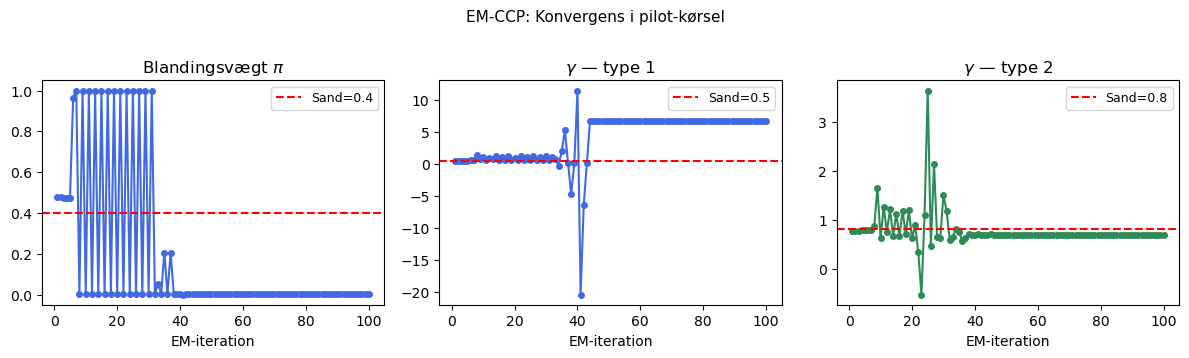

In [10]:
history = pilot_result['history']
iters   = range(1, len(history)+1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, vals, true_val, title, col in zip(
    axes,
    [[h['pi'] for h in history],
     [h['theta1'][1] for h in history],
     [h['theta2'][1] for h in history]],
    [PI_TRUE, THETA_1_TRUE[1], THETA_2_TRUE[1]],
    [r'Blandingsvægt $\pi$', r'$\gamma$ — type 1', r'$\gamma$ — type 2'],
    ['royalblue', 'royalblue', 'seagreen'],
):
    ax.plot(iters, vals, '-o', color=col, ms=4)
    ax.axhline(true_val, color='red', ls='--', lw=1.5, label=f'Sand={true_val}')
    ax.set_xlabel('EM-iteration'); ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle('EM-CCP: Konvergens i pilot-kørsel', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('ccp_em_convergence.pdf', bbox_inches='tight')
plt.show()

## 8. Monte Carlo-simulation

In [11]:
def run_monte_carlo_em_ccp(n_reps=EM_MC_REPS, n_consumers=EM_MC_N, seed=MC_SEED):
    """
    Monte Carlo for EM-CCP estimatoren.

    Hvert replikation:
      1. Simulér to-type panel.
      2. Initialiser start-CCPs fra VFI ved perturbererede startparametre.
      3. Estimer med EM-CCP.
      4. Anvend label-korrektion.
    """
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Sand DGP: løs DP én gang
    V1_t = solve_vfi(*unpack(THETA_1_TRUE));  P1_t = compute_ccps(V1_t, *unpack(THETA_1_TRUE))
    V2_t = solve_vfi(*unpack(THETA_2_TRUE));  P2_t = compute_ccps(V2_t, *unpack(THETA_2_TRUE))

    print(f'EM-CCP Monte Carlo  |  J={J}, T={T}, N={n_consumers}, K=2, reps={n_reps}')
    print(f'Sand theta_1: {dict(zip(PARAM_NAMES, np.round(THETA_1_TRUE,3)))}')
    print(f'Sand theta_2: {dict(zip(PARAM_NAMES, np.round(THETA_2_TRUE,3)))}')
    print(f'Sand pi = {PI_TRUE}\n')

    rows = []
    for rep in range(1, n_reps+1):
        data = simulate_panel_2types(P1_t, P2_t, pi_true=PI_TRUE,
                                     n_consumers=n_consumers, n_periods=T,
                                     seed=int(rep_seeds[rep-1]))

        rng_s   = np.random.default_rng(int(rep_seeds[rep-1]) + 999)
        t1_0    = THETA_1_TRUE + rng_s.normal(0.0, 0.04, 6)
        t2_0    = THETA_2_TRUE + rng_s.normal(0.0, 0.04, 6)
        pi0_rep = 0.50 + rng_s.uniform(-0.05, 0.05)
        if t1_0[1] > t2_0[1]:
            t1_0, t2_0 = t2_0, t1_0

        # Start-CCPs fra VFI ved startparametre
        V1_0 = solve_vfi(*unpack(t1_0));  P1_0 = compute_ccps(V1_0, *unpack(t1_0))
        V2_0 = solve_vfi(*unpack(t2_0));  P2_0 = compute_ccps(V2_0, *unpack(t2_0))

        t0     = time.perf_counter()
        em_res = estimate_em_ccp(data, pi0=pi0_rep,
                                 theta1_0=t1_0, theta2_0=t2_0,
                                 P1_init=P1_0, P2_init=P2_0,
                                 verbose=False)
        t_sec  = time.perf_counter() - t0

        pi_c, t1_c, t2_c = canonicalize(em_res['pi'], em_res['theta1'], em_res['theta2'])

        print(f"  Rep {rep:>3}/{n_reps}  conv={em_res['converged']}  "
              f"iter={em_res['n_iter']:>3}  pi={pi_c:.3f}  tid={t_sec:>6.1f}s")

        base = {'replication': rep, 'converged': int(em_res['converged']),
                'em_iter': em_res['n_iter'], 'time_sec': t_sec}
        rows.append({**base, 'parameter': 'pi', 'true': PI_TRUE,
                     'estimate': pi_c, 'bias': pi_c-PI_TRUE,
                     'sq_error': (pi_c-PI_TRUE)**2})
        for k, name in enumerate(PARAM_NAMES):
            for sfx, est, true in [('_k1', t1_c, THETA_1_TRUE), ('_k2', t2_c, THETA_2_TRUE)]:
                rows.append({**base, 'parameter': name+sfx,
                              'true': true[k], 'estimate': est[k],
                              'bias': est[k]-true[k],
                              'sq_error': (est[k]-true[k])**2})

    results_df = pd.DataFrame(rows)
    true_dict  = dict(zip(PARAM_NAMES_EM, THETA_EM_TRUE))
    summary_rows = []
    for name in PARAM_NAMES_EM:
        sub = results_df[results_df['parameter'] == name]
        est = sub['estimate'].to_numpy()
        summary_rows.append({'parameter': name, 'true': true_dict[name],
                             'mean_est': est.mean(), 'bias': sub['bias'].mean(),
                             'std_dev': est.std(ddof=1),
                             'rmse': np.sqrt(sub['sq_error'].mean()),
                             'conv_rate': sub['converged'].mean()})
    return results_df, pd.DataFrame(summary_rows)

In [12]:
results_df, summary_df = run_monte_carlo_em_ccp(
    n_reps=EM_MC_REPS, n_consumers=EM_MC_N, seed=MC_SEED
)

print('\n' + '='*70)
print('EM-CCP Monte Carlo — Opsummering  (K=2 typer)')
print('='*70)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('='*70)

results_df.to_csv('ccp_em_mc_results.csv', index=False)
summary_df.to_csv('ccp_em_mc_summary.csv', index=False)
print('\nResultater gemt: ccp_em_mc_results.csv og ccp_em_mc_summary.csv')

EM-CCP Monte Carlo  |  J=2, T=52, N=1000, K=2, reps=10
Sand theta_1: {'alpha_2': 0.3, 'gamma': 0.5, 'beta_sc_12': 0.55, 'beta_sc_21': 0.5, 'beta_dep_1': 0.25, 'beta_dep_2': 0.25}
Sand theta_2: {'alpha_2': 0.1, 'gamma': 0.8, 'beta_sc_12': 0.2, 'beta_sc_21': 0.15, 'beta_dep_1': 0.4, 'beta_dep_2': 0.4}
Sand pi = 0.4

  Rep   1/10  conv=False  iter=100  pi=0.999  tid= 187.7s


KeyboardInterrupt: 

## 9. Resultater

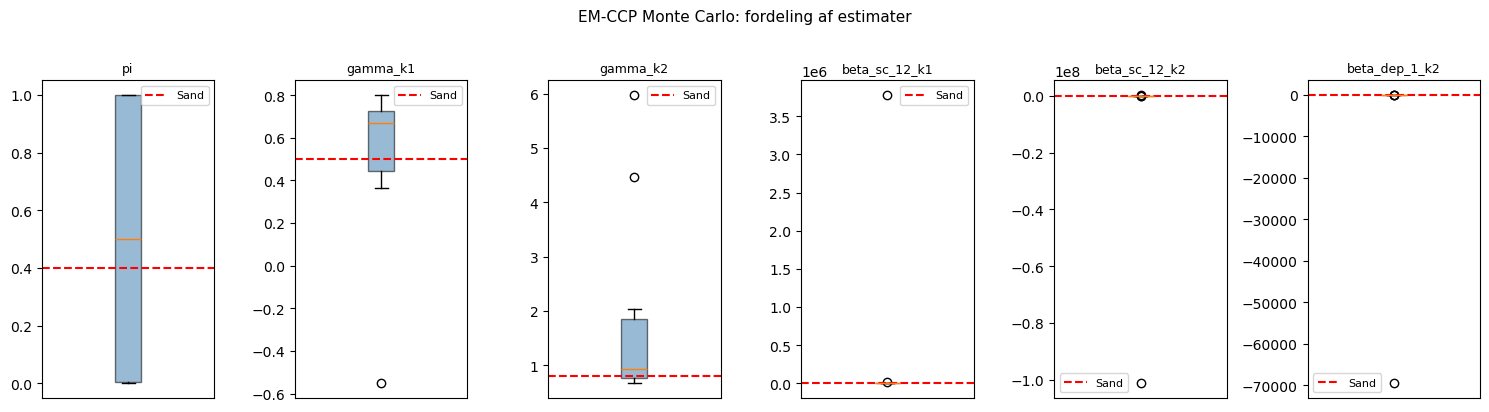

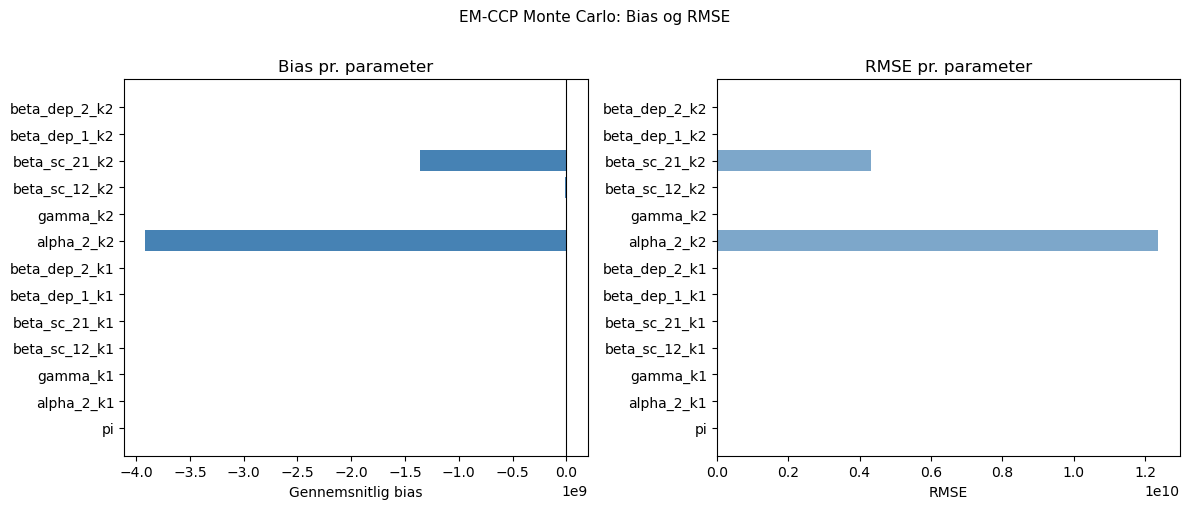

In [ ]:
key_params = ['pi', 'gamma_k1', 'gamma_k2', 'beta_sc_12_k1', 'beta_sc_12_k2', 'beta_dep_1_k2']
true_vals  = dict(zip(PARAM_NAMES_EM, THETA_EM_TRUE))

fig, axes = plt.subplots(1, len(key_params), figsize=(15, 4))
for ax, pname in zip(axes, key_params):
    sub = results_df[results_df['parameter'] == pname]['estimate']
    ax.boxplot(sub, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.55))
    ax.axhline(true_vals[pname], color='red', ls='--', lw=1.5, label='Sand')
    ax.set_title(pname, fontsize=9); ax.set_xticks([]); ax.legend(fontsize=8)

plt.suptitle('EM-CCP Monte Carlo: fordeling af estimater', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('ccp_em_boxplots.pdf', bbox_inches='tight')
plt.show()

# Bias/RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(summary_df['parameter'], summary_df['bias'],
             color=['salmon' if b>0 else 'steelblue' for b in summary_df['bias']])
axes[0].axvline(0, color='k', lw=0.8); axes[0].set_xlabel('Gennemsnitlig bias')
axes[0].set_title('Bias pr. parameter')
axes[1].barh(summary_df['parameter'], summary_df['rmse'], color='steelblue', alpha=0.7)
axes[1].set_xlabel('RMSE'); axes[1].set_title('RMSE pr. parameter')
plt.suptitle('EM-CCP Monte Carlo: Bias og RMSE', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('ccp_em_bias_rmse.pdf', bbox_inches='tight')
plt.show()